# Mutual Fund Analytics Capstone

## Day 3: KPI Analytics & Dashboard Preparation

### Objectives

- Calculate key business KPIs
- Analyze investor activity
- Analyze SIP growth trends
- Evaluate portfolio composition
- Assess fund performance using returns, alpha and Sharpe ratio
- Prepare dashboard-ready metrics

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

# Load Datasets

In [2]:
funds = pd.read_csv("../Bluestock-Capstone/data/raw/01_fund_master.csv")

sip = pd.read_csv("../Bluestock-Capstone/data/raw/04_monthly_sip_inflows.csv")

investors = pd.read_csv("../Bluestock-Capstone/data/raw/08_investor_transactions.csv")

portfolio = pd.read_csv("../Bluestock-Capstone/data/raw/09_portfolio_holdings.csv")

performance = pd.read_csv("../Bluestock-Capstone/data/raw/07_scheme_performance.csv")

print("Datasets Loaded Successfully")

Datasets Loaded Successfully


# Fund KPIs

In [3]:
total_funds = funds["amfi_code"].nunique()

total_fund_houses = funds["fund_house"].nunique()

avg_expense_ratio = round(
    funds["expense_ratio_pct"].mean(),
    2
)

avg_aum = round(
    performance["aum_crore"].mean(),
    2
)

print("Total Funds:", total_funds)
print("Total Fund Houses:", total_fund_houses)
print("Average Expense Ratio:", avg_expense_ratio)
print("Average AUM:", avg_aum)

Total Funds: 40
Total Fund Houses: 10
Average Expense Ratio: 1.24
Average AUM: 26091.6


# Investor KPIs

In [4]:
total_investors = investors["investor_id"].nunique()

total_transactions = len(investors)

total_investment = investors["amount_inr"].sum()

avg_transaction = investors["amount_inr"].mean()

print("Total Investors:", total_investors)
print("Total Transactions:", total_transactions)
print("Total Investment:", round(total_investment,2))
print("Average Transaction Size:", round(avg_transaction,2))

Total Investors: 5000
Total Transactions: 32778
Total Investment: 3521580430
Average Transaction Size: 107437.32


In [5]:
total_investors = investors["investor_id"].nunique()

total_transactions = len(investors)

total_investment = investors["amount_inr"].sum()

avg_transaction = investors["amount_inr"].mean()

print("Total Investors:", total_investors)
print("Total Transactions:", total_transactions)
print("Total Investment:", round(total_investment,2))
print("Average Transaction Size:", round(avg_transaction,2))

Total Investors: 5000
Total Transactions: 32778
Total Investment: 3521580430
Average Transaction Size: 107437.32


# SIP KPIs

In [6]:
latest_sip = sip.iloc[-1]["sip_inflow_crore"]

max_sip = sip["sip_inflow_crore"].max()

avg_sip = sip["sip_inflow_crore"].mean()

print("Latest SIP:", latest_sip)
print("Maximum SIP:", max_sip)
print("Average SIP:", round(avg_sip,2))

Latest SIP: 31002
Maximum SIP: 31002
Average SIP: 19577.52


# Portfolio KPIs

In [7]:
sector = (
    portfolio.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

sector.head(10)

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
Name: weight_pct, dtype: float64

## Top Sector Analysis

In [8]:
print("Top Sector:", sector.index[0])

print("Number of Sectors:",
      portfolio["sector"].nunique())

print("Average Weight:",
      round(
          portfolio["weight_pct"].mean(),
          2
      ))

Top Sector: Banking
Number of Sectors: 14
Average Weight: 10.56


# Fund Performance Analysis

In [9]:
top_returns = (
    performance.sort_values(
        "return_5yr_pct",
        ascending=False
    )
    [["scheme_name","return_5yr_pct"]]
    .head(10)
)

top_returns

,scheme_name,return_5yr_pct
29,ABSL Small Cap Fund - Regular - Growth,23.80
27,Axis Small Cap Fund - Regular - Growth,22.62
17,Nippon India Small Cap Fund - Regular - Growth,21.88
3,SBI Small Cap Fund - Direct Plan - Growth,21.82
2,SBI Small Cap Fund - Regular Plan - Growth,20.67
39,DSP Small Cap Fund - Regular - Growth,20.61
38,DSP Midcap Fund - Regular - Growth,19.00
26,Axis Midcap Fund - Regular - Growth,18.94
21,Kotak Emerging Equity Fund - Regular - Growth,17.75
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,17.69


## Top 10 Funds by 5-Year Return

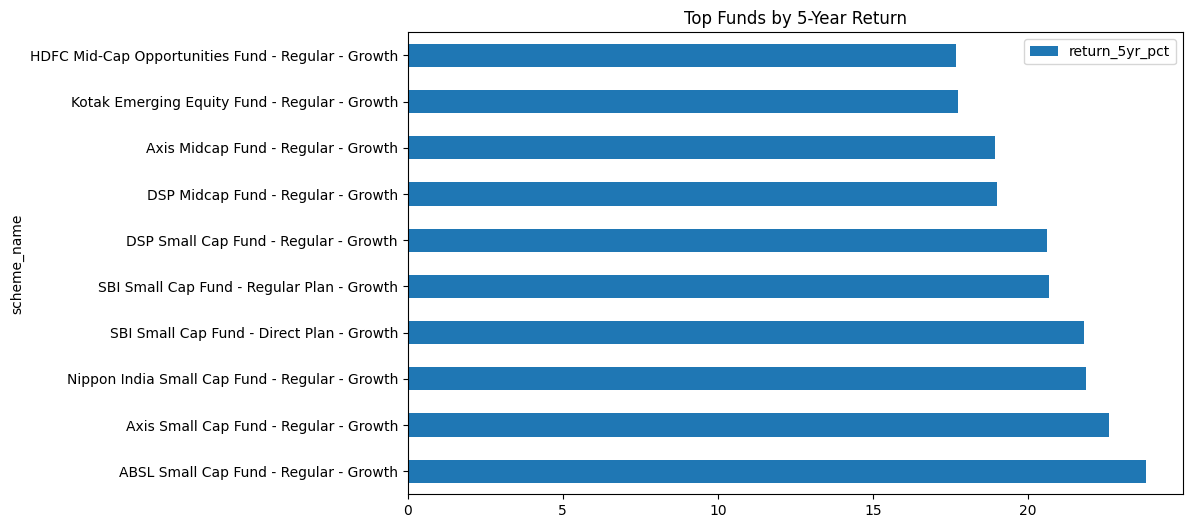

In [10]:
top_returns.plot(
    x="scheme_name",
    y="return_5yr_pct",
    kind="barh",
    figsize=(10,6)
)

plt.title("Top Funds by 5-Year Return")
plt.show()

In [11]:
top_alpha = (
    performance.sort_values(
        "alpha",
        ascending=False
    )
    [["scheme_name","alpha"]]
    .head(10)
)

top_alpha

,scheme_name,alpha
9,HDFC Short Term Debt Fund - Regular - Growth,1.98
21,Kotak Emerging Equity Fund - Regular - Growth,1.91
14,ICICI Pru Liquid Fund - Regular - Growth,1.85
22,Kotak Flexicap Fund - Regular - Growth,1.85
29,ABSL Small Cap Fund - Regular - Growth,1.84
37,DSP Top 100 Equity Fund - Regular - Growth,1.82
18,Nippon India ETF Nifty 50 BeES,1.80
33,UTI Flexi Cap Fund - Regular - Growth,1.79
1,SBI Bluechip Fund - Direct Plan - Growth,1.78
35,Mirae Asset Emerging Bluechip Fund - Regular -...,1.70


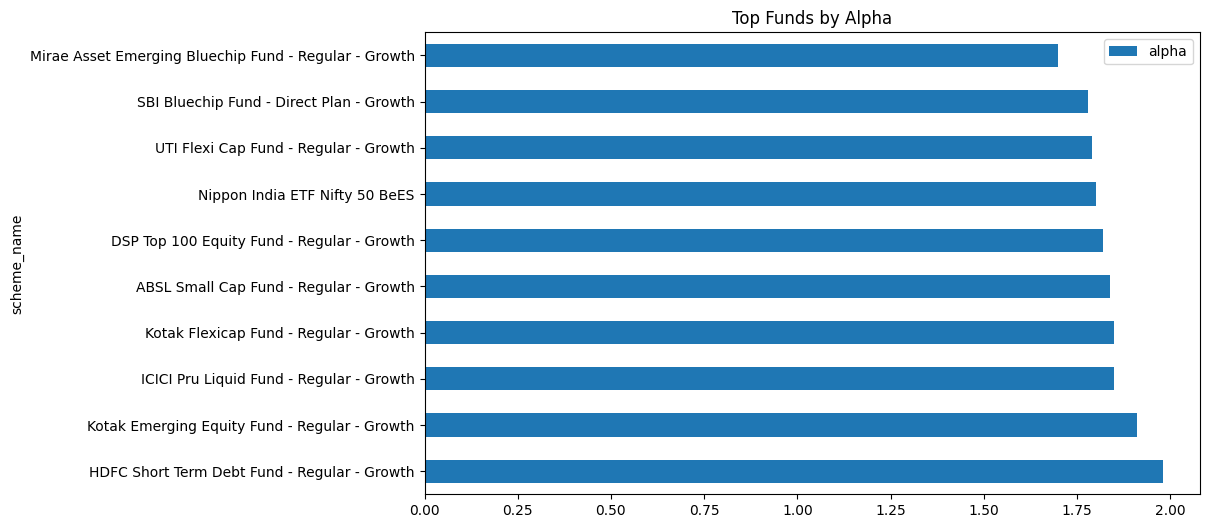

In [12]:
top_alpha.plot(
    x="scheme_name",
    y="alpha",
    kind="barh",
    figsize=(10,6)
)

plt.title("Top Funds by Alpha")
plt.show()

In [13]:
top_sharpe = (
    performance.sort_values(
        "sharpe_ratio",
        ascending=False
    )
    [["scheme_name","sharpe_ratio"]]
    .head(10)
)

top_sharpe

,scheme_name,sharpe_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,7.68
23,Kotak Liquid Fund - Regular - Growth,6.18
30,ABSL Liquid Fund - Regular - Growth,5.14
9,HDFC Short Term Debt Fund - Regular - Growth,1.84
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.52
19,Nippon India Gilt Securities Fund - Regular - ...,1.33
34,Mirae Asset Large Cap Fund - Regular - Growth,1.06
5,HDFC Top 100 Fund - Regular Plan - Growth,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,1.03
15,Nippon India Large Cap Fund - Regular - Growth,1.00


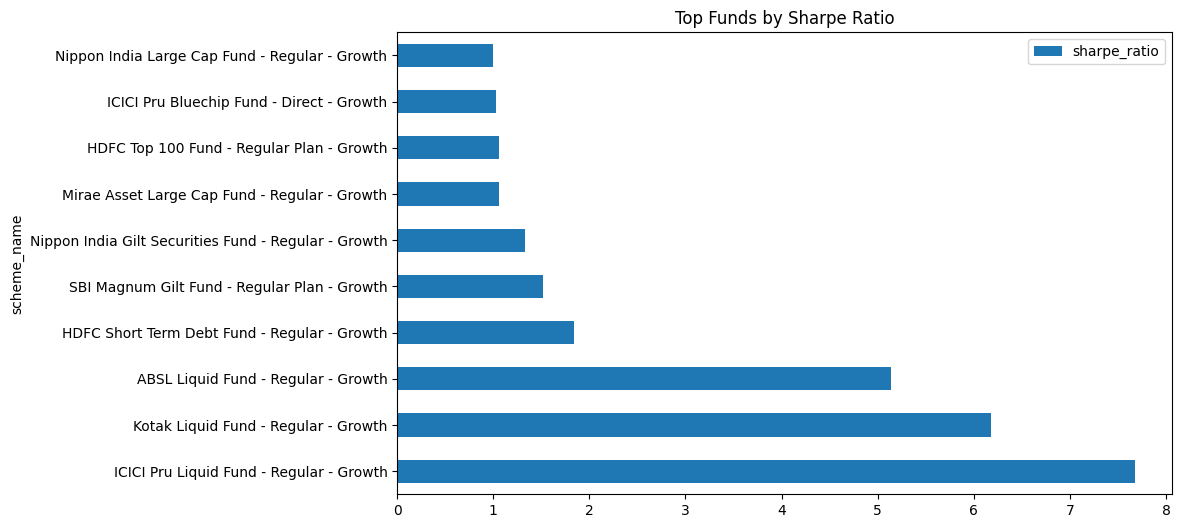

In [14]:
top_sharpe.plot(
    x="scheme_name",
    y="sharpe_ratio",
    kind="barh",
    figsize=(10,6)
)

plt.title("Top Funds by Sharpe Ratio")
plt.show()

# Business Insights

### Key Findings

1. Total Funds Available: 40

2. Total Fund Houses: 10

3. SIP inflows continue to grow and reached a maximum of ₹31,002 Crore.

4. Banking remains the dominant portfolio sector.

5. Small-cap funds generated the highest long-term returns.

6. Liquid funds delivered the strongest risk-adjusted performance.

7. Certain funds generated positive alpha, outperforming their benchmark.

# Dashboard Planning

The calculated KPIs and performance metrics will be used to build:

- Executive Dashboard
- Investor Analytics Dashboard
- SIP Growth Dashboard
- Portfolio Analytics Dashboard
- Fund Performance Dashboard

# Conclusion

Day 3 focused on KPI generation and fund performance analysis.

The project now contains:

- ETL Pipeline
- PostgreSQL Database
- Exploratory Data Analysis
- KPI Analytics
- Dashboard Requirements

The next phase will involve dashboard development and deployment.